<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/m_layer_spiral_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M-Layer Spiral Classification (PyTorch)

Replicating **Figure 2** from:
> Fischbacher et al., "Intelligent Matrix Exponentiation", [arXiv:2008.03936](https://arxiv.org/abs/2008.03936)

Original github repo: [google-research/m-layer](https://github.com/google-research/google-research/tree/master/m_layer)

This demonstrates the M-layer's ability to **extrapolate** on spiral data, compared to standard DNNs.

In [ ]:
import torch
import torch. nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch. cuda.is_available() else 'cpu')
print(f"Using device: {device}")

## 1. M-Layer Implementation

In [ ]:
class GLU(nn.Module):
    """
    Gated Linear Unit with a logistic-scaled Gaussian gate.
    # gaussian tricks by Piyush Sao

    The gate uses erf scaled by 1/sqrt(3) so the raw output lives in
    (0.5 - 1/(2*sqrt(3)), 0.5 + 1/(2*sqrt(3))) — never reaching 0 or 1.
    An affine rescaling maps this to [0, 1] on the forward pass, with a
    straight-through estimator passing gradients from the unscaled gate.

    The erf argument is scaled by pi/sqrt(3) / sqrt(2) = pi/sqrt(6),
    matching the logistic CDF shape while remaining entire (no complex
    singularities).
    """

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.W = nn.Linear(d_model, d_ff, bias=False)
        self.W_gate = nn.Linear(d_model, d_ff, bias=False)
        self.W_out = nn.Linear(d_ff, d_model, bias=False)

        # exact constants from the logistic-Gaussian relationship
        self.register_buffer(
            'gate_lo', torch.tensor(0.5 - 1.0 / (2.0 * math.sqrt(3)))
        )
        self.register_buffer(
            'gate_hi', torch.tensor(0.5 + 1.0 / (2.0 * math.sqrt(3)))
        )
        self.register_buffer(
            'gate_range', torch.tensor(1.0 / math.sqrt(3))
        )
        # pi/sqrt(6) = pi / (sqrt(3) * sqrt(2))
        self.register_buffer(
            'erf_scale', torch.tensor(math.pi / math.sqrt(6))
        )

    def forward(self, x):
        z = self.W_gate(x)

        # raw gate in (gate_lo, gate_hi), never 0 or 1
        gate_raw = 0.5 * (1.0 + torch.erf(self.erf_scale * z) / math.sqrt(3))

        # rescale to [0, 1] on forward, straight-through on backward
        gate_scaled = (gate_raw - self.gate_lo) / self.gate_range
        gate = gate_raw + (gate_scaled - gate_raw).detach()

        return self.W_out(gate * self.W(x))


## 2. Generate Spiral Data

In [ ]:
def generate_spiral(n_points, noise=0.5, rng=None, extra_rotation=False):
    """Generate two interleaved spirals.

    Args:
        n_points: Number of points per class
        noise: Amount of noise to add
        rng: Random state
        extra_rotation:  If True, generate points further out (for extrapolation test)

    Returns:
        X: (2*n_points, 2) coordinates
        y: (2*n_points,) labels (0 or 1)
    """
    if rng is None:
        rng = np.random.RandomState()

    if not extra_rotation:
        # Training data:  inner part of spiral
        n = np.sqrt(0.001 + 0.25 * rng.rand(n_points, 1)) * 6 * (2 * np.pi)
    else:
        # Test data: outer part of spiral (extrapolation)
        n = np.sqrt((7.0/36) * rng.rand(n_points, 1) + 0.25) * 6 * (2 * np.pi)

    x = 0.5 * (np.sin(n) * n + (2 * rng.rand(n_points, 1) - 1) * noise)
    y = 0.5 * (np.cos(n) * n + (2 * rng. rand(n_points, 1) - 1) * noise)

    # Class 0: (x, y), Class 1: (-x, -y)
    X = np.vstack([np.hstack([x, y]), np.hstack([-x, -y])])
    labels = np.hstack([np.zeros(n_points), np.ones(n_points)])

    return X. astype(np.float32), labels.astype(np.float32)

# Generate data
X_train, y_train = generate_spiral(1000, rng=np.random.RandomState(1))
X_test, y_test = generate_spiral(333, extra_rotation=True, rng=np. random.RandomState(2))

# Visualize
plt.figure(figsize=(8, 8))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', s=3, alpha=0.6, label='Train Class 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='red', s=3, alpha=0.6, label='Train Class 1')
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='cyan', s=1, alpha=0.8, label='Test Class 0 (extrapolation)')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='orange', s=1, alpha=0.8, label='Test Class 1 (extrapolation)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.title('Spiral Dataset:  Train (inner) vs Test (outer, extrapolation)')
plt.show()

## 3. Define Models

In [ ]:
# Hyperparameters (matching the paper)
DIM_REP = 10       # Intermediate representation dimension
DIM_MATRIX = 10    # M-layer matrix size
LAYER_SIZE = 35    # DNN hidden layer size (Increased for comparable parameters)
LR = 0.01
EPOCHS = 500
BATCH_SIZE = 16


class DNNModel(nn.Module):
    """Standard DNN classifier."""
    def __init__(self, activation='relu'):
        super().__init__()
        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()
        self.net = nn.Sequential(
            nn.Linear(2, LAYER_SIZE),
            GLU(LAYER_SIZE, LAYER_SIZE),
            nn.Linear(LAYER_SIZE, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)



## 4. Training Loop

In [ ]:
def train_model(model, X_train, y_train, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, patience=50, verbose=True):
    """Train a model with early stopping."""
    model = model.to(device)
    X = torch.tensor(X_train).to(device)
    y = torch.tensor(y_train).to(device)

    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.2, min_lr=1e-5)
    criterion = nn.BCELoss()

    losses = []
    best_loss = float('inf')
    patience_counter = 0
    best_state = None

    n_samples = len(X)

    for epoch in range(epochs):
        model.train()

        # Shuffle
        perm = torch.randperm(n_samples)
        X_shuffled = X[perm]
        y_shuffled = y[perm]

        epoch_loss = 0
        n_batches = 0

        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss. backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses. append(avg_loss)
        scheduler.step(avg_loss)

        # Early stopping
        if avg_loss < best_loss - 0.0001:
            best_loss = avg_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        if verbose and (epoch + 1) % 100 == 0:
            acc = ((model(X) > 0.5).float() == y).float().mean().item()
            print(f"Epoch {epoch+1}:  Loss = {avg_loss:.4f}, Acc = {acc:.4f}")

    # Restore best weights
    if best_state is not None:
        model. load_state_dict(best_state)
        model = model.to(device)

    return model, losses

## 5. Visualization Function (Decision Boundary)

In [ ]:
def plot_decision_boundary(model, X_train, y_train, X_test, y_test, title="", ax=None):
    """Plot decision boundary with training and test points."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    model.eval()

    # Create grid for decision boundary
    delta = 0.125  # Grid resolution
    x_range = np.arange(-14, 14.01, delta)
    y_range = np. arange(-14, 14.01, delta)
    XX, YY = np.meshgrid(x_range, y_range)

    grid_points = np.column_stack([XX. ravel(), YY.ravel()]).astype(np.float32)
    grid_tensor = torch.tensor(grid_points).to(device)

    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(XX.shape)

    # Plot decision regions
    ax.contourf(XX, YY, Z, levels=[0.0, 0.5, 1.0],
                colors=[(0.41, 0.67, 0.81, 0.3), (0.89, 0.51, 0.41, 0.3)])

    # Plot decision boundary
    ax. contour(XX, YY, Z, levels=[0.5], colors='black', linewidths=1.5)

    # Plot training points
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               c='#4A90D9', s=4, alpha=0.7, label='Train Class 0')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               c='#D96459', s=4, alpha=0.7, label='Train Class 1')

    # Plot test points (extrapolation region)
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
               c='#4A90D9', s=1, alpha=0.9, marker='.')
    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
               c='#D96459', s=1, alpha=0.9, marker='.')

    ax. set_xlim(-14, 14)
    ax. set_ylim(-14, 14)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax. set_title(title, fontsize=14)

    return ax

## 6. Train and Compare Models (Figure 2)

In [ ]:
# Train DNN with ReLU
print("="*50)
print("Training DNN (ReLU)")
print("="*50)
torch.manual_seed(42)
dnn_relu = DNNModel(activation='relu')
dnn_relu, dnn_relu_losses = train_model(dnn_relu, X_train, y_train)

In [ ]:
print(f"DNN (ReLU) Parameters: {sum(p.numel() for p in dnn_relu.parameters())}")


In [ ]:
# Evaluate on test set (extrapolation)
def evaluate(model, X, y):
    model.eval()
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    with torch.no_grad():
        preds = model(X_t)
        acc = ((preds > 0.5).float() == y_t).float().mean().item()
    return acc

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"{'Model':<20} {'Train Acc':<12} {'Test Acc (Extrapolation)'}")
print("-"*50)
print(f"{'DNN (ReLU)':<20} {evaluate(dnn_relu, X_train, y_train):.4f}       {evaluate(dnn_relu, X_test, y_test):.4f}")


## 7. Plot Figure 2: Decision Boundaries Comparison

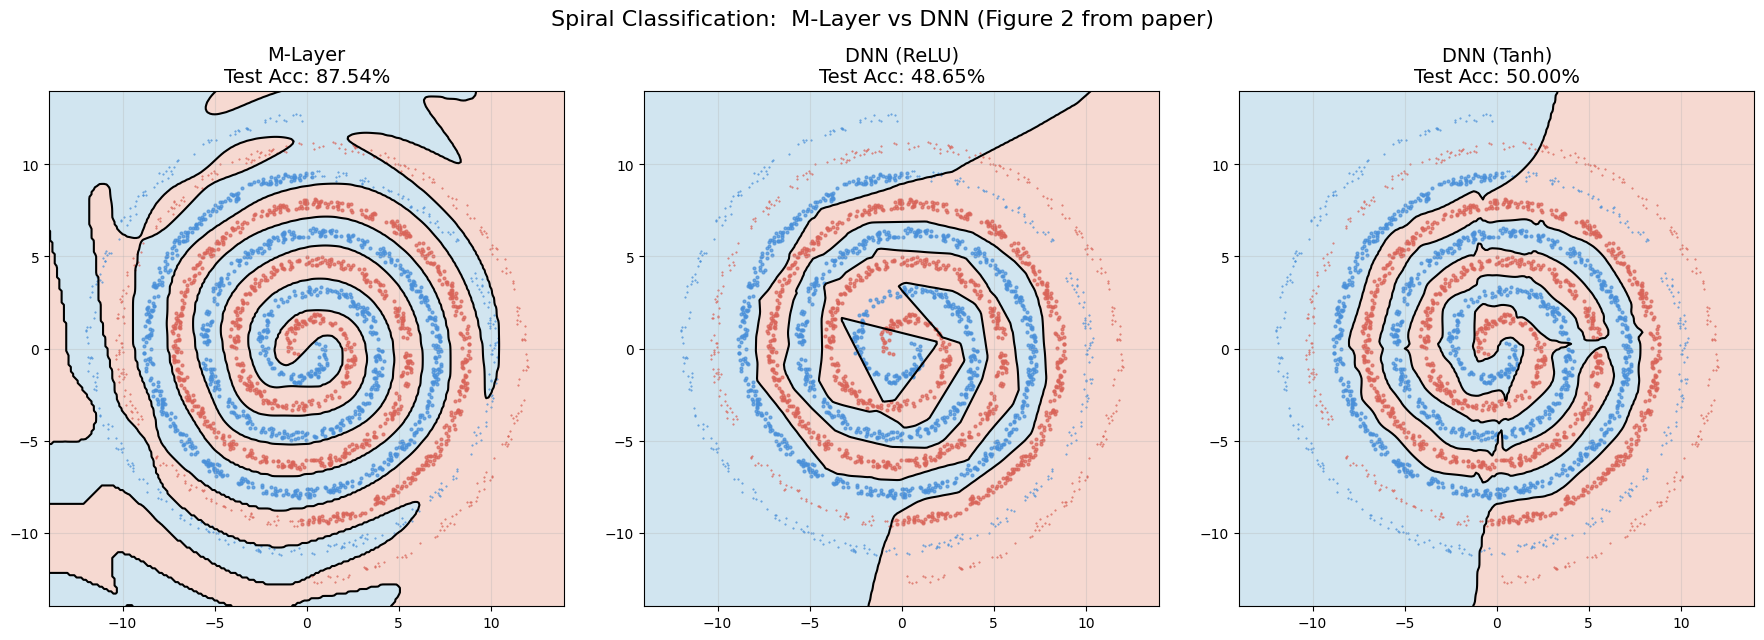

In [ ]:
fig, axes = plt. subplots(1, 1, figsize=(18, 6))

plot_decision_boundary(dnn_relu, X_train, y_train, X_test, y_test,
                       title=f"DNN (ReLU)\nTest Acc: {evaluate(dnn_relu, X_test, y_test):.2%}",
                       ax=axes[0])


plt. suptitle('Spiral Classification:  M-Layer vs DNN (Figure 2 from paper)', fontsize=16, y=1.02)
plt.tight_layout()
plt. savefig('figure2_spiral_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Training Loss Comparison

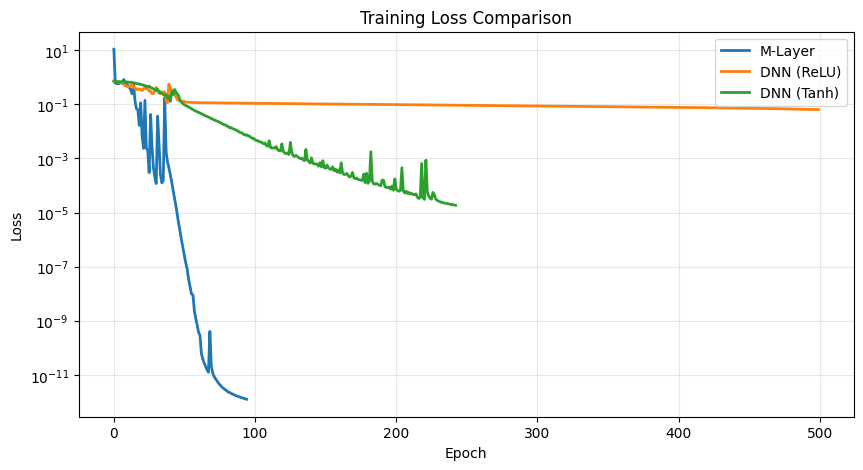

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(m_layer_losses, label='M-Layer', linewidth=2)
plt. plot(dnn_relu_losses, label='DNN (ReLU)', linewidth=2)
plt. plot(dnn_tanh_losses, label='DNN (Tanh)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt. yscale('log')
plt.grid(True, alpha=0.3)
plt. show()

## 9. Key Observations

**From Figure 2 (replicating the paper):**

1. **M-Layer extrapolates well**: The decision boundary continues the spiral pattern into the outer region (test data), correctly classifying extrapolation points.

2. **DNN (ReLU) fails to extrapolate**:  The decision boundary becomes piecewise linear and does not follow the spiral structure outside the training region.

3. **DNN (Tanh) also struggles**: While smoother than ReLU, it still fails to capture the rotational/periodic structure needed for extrapolation.

**Why M-Layer works:**
- The matrix exponential naturally produces **rotation-like** transformations
- It learns the underlying **Lie group structure** of the spiral
- Extrapolation = continuing the learned rotation, which exp(M) does naturally

## 10. Bonus: Visualize Learned Generator Matrices

Generator shape: (10, 10, 10)


/tmp/ipython-input-3089337650.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


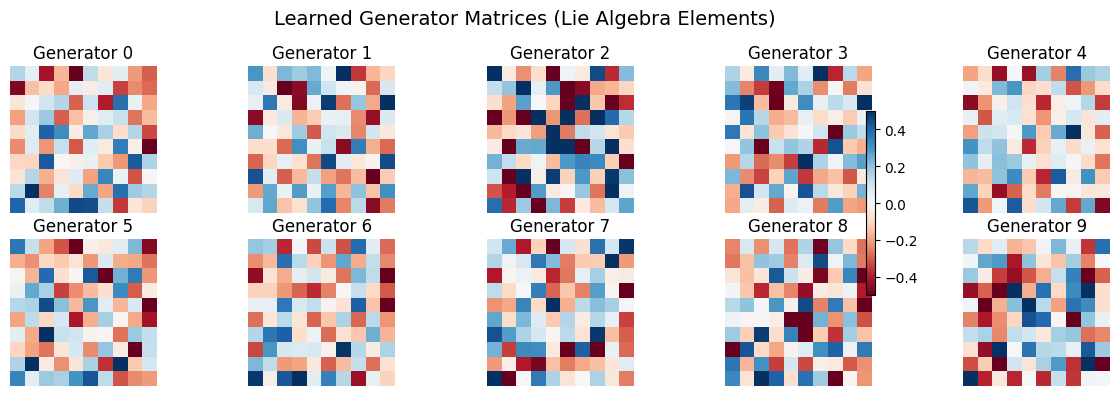

In [ ]:
# Extract the M-Layer from the model
m_layer = m_layer_model.net[1]

generators = m_layer.generators. detach().cpu().numpy()
print(f"Generator shape: {generators.shape}")

# Plot first few generators
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes. flat):
    if i < generators.shape[0]:
        im = ax.imshow(generators[i], cmap='RdBu', vmin=-0.5, vmax=0.5)
        ax.set_title(f'Generator {i}')
        ax.axis('off')

plt.colorbar(im, ax=axes, shrink=0.6)
plt.suptitle('Learned Generator Matrices (Lie Algebra Elements)', fontsize=14)
plt.tight_layout()
plt.show()